In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, LearningRateScheduler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import sklearn.metrics as metrics

annealer = LearningRateScheduler(lambda epoch: 1e-3 * (0.95 ** epoch), verbose=0)

In [2]:
import os
import pandas as pd

base_dir = "AugmentedAlzheimerDataset"

MildDemented_dir = os.path.join(base_dir, "MildDemented")
ModerateDemented_dir = os.path.join(base_dir, "ModerateDemented")
NonDemented_dir = os.path.join(base_dir, "NonDemented")
VeryMildDemented_dir = os.path.join(base_dir, "VeryMildDemented")

filepaths = []
labels = []
dict_list = [MildDemented_dir, ModerateDemented_dir, NonDemented_dir, VeryMildDemented_dir]
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

for i, j in enumerate(dict_list):
    flist = os.listdir(j)
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
Alzheimer_data = pd.concat([Fseries, Lseries], axis=1)
Alzheimer_df = pd.DataFrame(Alzheimer_data)
print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())

                                           filepaths         labels
0  AugmentedAlzheimerDataset\MildDemented\002cb9c...  Mild Demented
1  AugmentedAlzheimerDataset\MildDemented\0033c40...  Mild Demented
2  AugmentedAlzheimerDataset\MildDemented\00372fb...  Mild Demented
3  AugmentedAlzheimerDataset\MildDemented\00387cf...  Mild Demented
4  AugmentedAlzheimerDataset\MildDemented\0045bd9...  Mild Demented
labels
Non Demented         9600
Very MildDemented    8960
Mild Demented        8954
Moderate Demented    6464
Name: count, dtype: int64


In [3]:
Alzheimer_df.shape

(33978, 2)

In [4]:
train_images, test_images = train_test_split(Alzheimer_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(Alzheimer_df, test_size=0.2, random_state=42)

In [5]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(27182, 2)
(10194, 2)
(6796, 2)
(23784, 2)


In [6]:
image_gen = ImageDataGenerator(preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe= train_set,x_col="filepaths",y_col="labels",
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode="categorical", #used for Sequential Model
                                      batch_size=32,
                                      shuffle=False            #do not shuffle data
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(244,244),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(244,244),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )

Found 27182 validated image filenames belonging to 4 classes.
Found 10194 validated image filenames belonging to 4 classes.
Found 6796 validated image filenames belonging to 4 classes.


In [7]:
classes=list(train.class_indices.keys())
print (classes)

['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']


In [8]:
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()

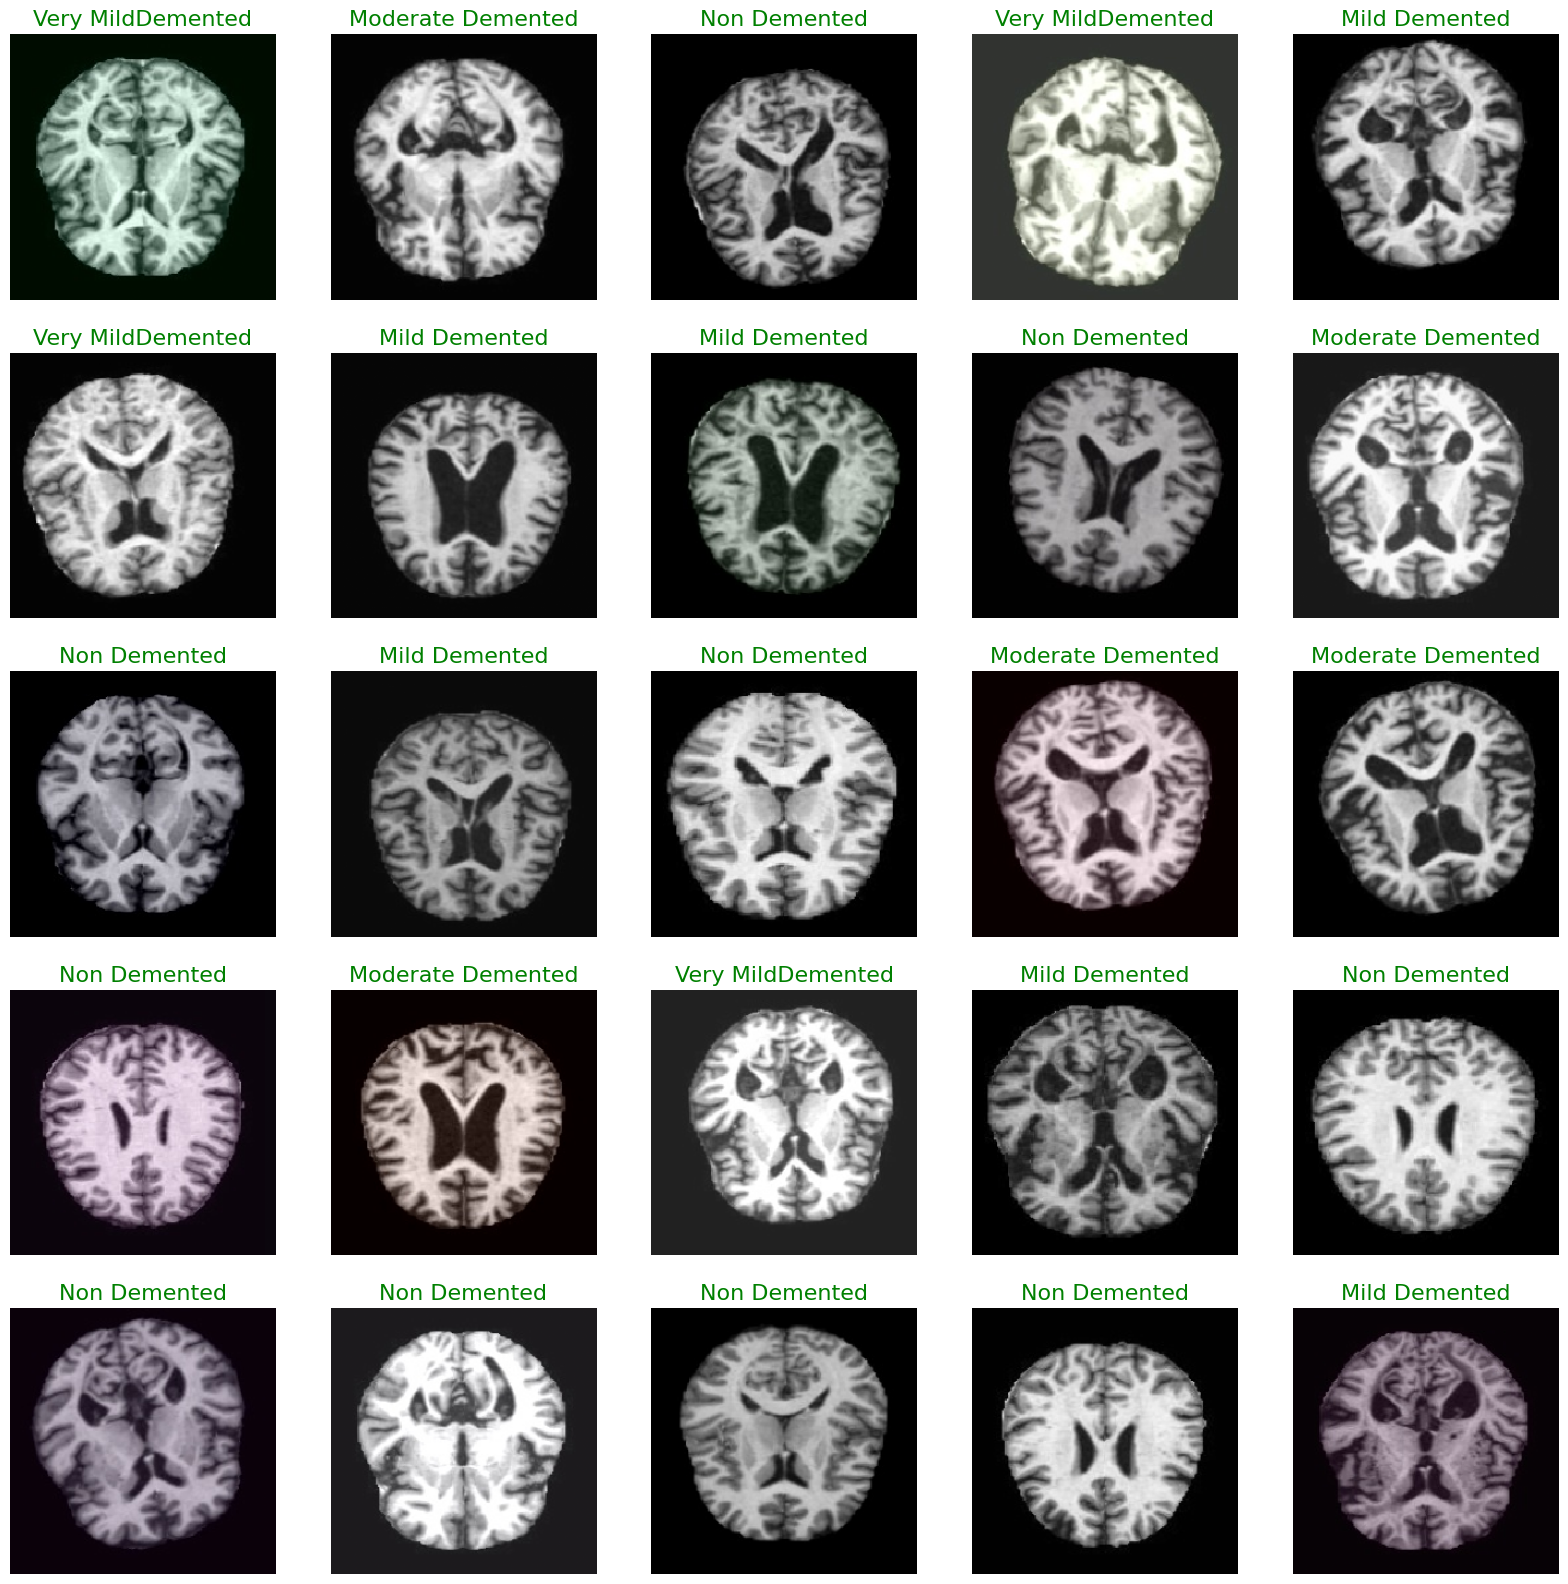

In [9]:
show_knee_images(train)

In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=(244, 244, 3)),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(3, 3)),
    
    tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 79, 79, 128)       24704     
                                                                 
 batch_normalization (BatchN  (None, 79, 79, 128)      512       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 79, 79, 256)       819456    
                                                                 
 batch_normalization_1 (Batc  (None, 79, 79, 256)      1024      
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 26, 26, 256)      0         
 )                                                               
                                                        

In [11]:
history = model.fit(train, epochs=22, validation_data=val, validation_freq=1)

Epoch 1/22
850/850 [==============================] - 123s 129ms/step - loss: 1.3933 - accuracy: 0.4061 - val_loss: 0.9937 - val_accuracy: 0.5536
Epoch 2/22
850/850 [==============================] - 103s 121ms/step - loss: 0.9870 - accuracy: 0.5461 - val_loss: 0.8415 - val_accuracy: 0.6232
Epoch 3/22
850/850 [==============================] - 103s 121ms/step - loss: 0.8543 - accuracy: 0.5965 - val_loss: 0.7382 - val_accuracy: 0.6604
Epoch 4/22
850/850 [==============================] - 102s 121ms/step - loss: 0.7746 - accuracy: 0.6419 - val_loss: 0.6919 - val_accuracy: 0.6838
Epoch 5/22
850/850 [==============================] - 103s 121ms/step - loss: 0.6968 - accuracy: 0.6799 - val_loss: 0.6168 - val_accuracy: 0.7270
Epoch 6/22
850/850 [==============================] - 103s 121ms/step - loss: 0.6263 - accuracy: 0.7165 - val_loss: 0.5768 - val_accuracy: 0.7348
Epoch 7/22
850/850 [==============================] - 102s 120ms/step - loss: 0.5487 - accuracy: 0.7597 - val_loss: 0.5021 -

In [12]:
model.evaluate(test, verbose=1)

319/319 [==============================] - 12s 36ms/step - loss: 0.2325 - accuracy: 0.9352


[0.2324860394001007, 0.9351579546928406]

In [14]:
model.save("Alzheimer_Model.h5")

In [15]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1) #pick class with highest  probability

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

319/319 [==============================] - 10s 31ms/step


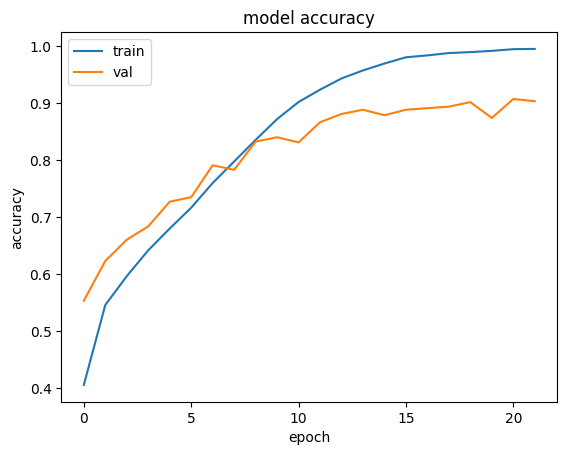

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

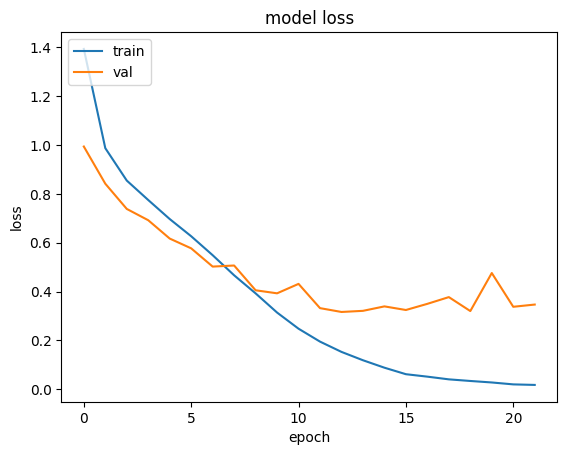

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

                   precision    recall  f1-score   support

    Mild Demented       0.95      0.94      0.94      2692
Moderate Demented       0.99      1.00      0.99      1977
     Non Demented       0.96      0.89      0.92      2798
Very MildDemented       0.87      0.93      0.90      2727

         accuracy                           0.94     10194
        macro avg       0.94      0.94      0.94     10194
     weighted avg       0.94      0.94      0.94     10194

Accuracy of the Model: 93.5%


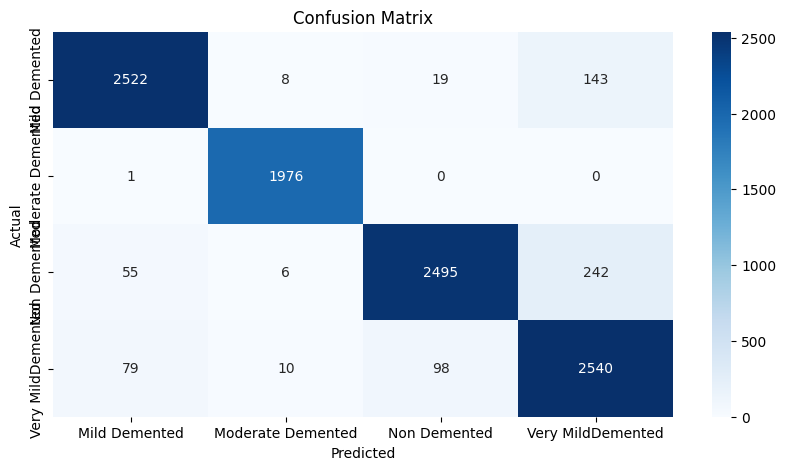

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the class labels
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred2)

# Create a figure and plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

# Set tick labels and axis labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Set the title
plt.title("Confusion Matrix")

# Show the plot
plt.show()